AICTE | IBM SkillsBuild Data Analytics with AI Internship 2026

Project:
RailSense: Indian Railway Punctuality & Delay Analytics

Submitted by:
DIVYANSHU SINGH

College:
VIT Chennai

Program:
M.Tech Software Engineering

#  RailSense: Indian Railway Punctuality & Delay Analytics

### AICTE | IBM SkillsBuild Data Analytics with AI Internship 2026

**Project:** Data-driven analysis of Indian railway train–station punctuality patterns using exploratory data analysis, visualization, clustering, and anomaly detection.

---

## Project objective

This notebook analyzes historical Indian railway delay observations at the **train–station level**.

We will:

1. Clean and validate the dataset.
2. Explore delay and punctuality patterns.
3. Identify stations and trains with different delay profiles.
4. Analyze relationships between punctuality and delay severity.
5. Use **K-Means clustering** to discover train–station delay profiles.
6. Use **Isolation Forest** to identify unusual delay observations.
7. Generate evidence-based findings and conclusions.

> **Important methodological note:** This dataset contains aggregated historical delay statistics rather than individual future journeys. Therefore, this project does **not** claim to predict the exact delay of a future train journey. The AI component is used for historical pattern discovery and anomaly detection.


## 1. Environment Setup

You can also mount Google Drive if you want persistent storage.


In [1]:
# Install / verify required libraries
!pip -q install pandas numpy matplotlib seaborn scikit-learn openpyxl

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries loaded successfully.")


Libraries loaded successfully.


## 2. Load the Dataset


`etrain_delays.csv`

The uploaded dataset contains **1,900 train–station observations and 11 columns**.

The main fields are:

- `train_number`
- `train_name`
- `station_code`
- `station_name`
- `average_delay_minutes`
- `pct_right_time`
- `pct_slight_delay`
- `pct_significant_delay`
- `pct_cancelled_unknown`
- `scraped_at`
- `source_url`


In [2]:
# Try the standard Colab upload location first.
from pathlib import Path

DATA_PATH = "/content/etrain_delays.csv"

if not Path(DATA_PATH).exists():
    print("Dataset not found at /content/etrain_delays.csv")
    print("Use the next cell to upload the CSV file manually.")
else:
    df = pd.read_csv(DATA_PATH)
    print(f"Loaded dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
    display(df.head())


Loaded dataset: 1,900 rows × 11 columns


,train_number,train_name,station_code,station_name,average_delay_minutes,pct_right_time,pct_slight_delay,pct_significant_delay,pct_cancelled_unknown,scraped_at,source_url
0,12673,Cheran Express,MAS,CHENNAI CENTRAL,2.0,98.90,0.27,0.00,0.83,2025-09-27T12:25:37.767628+00:00,https://etrain.info/train/Cheran-Express-12673...
1,12673,Cheran Express,AVD,AVADI,0.0,0.27,0.00,0.00,99.73,2025-09-27T12:25:39.293769+00:00,https://etrain.info/train/Cheran-Express-12673...
2,12673,Cheran Express,AJJ,ARAKKONAM,16.0,55.34,44.38,0.27,0.01,2025-09-27T12:25:40.672610+00:00,https://etrain.info/train/Cheran-Express-12673...
3,12673,Cheran Express,KPD,KATPADI JN,17.0,48.49,49.86,1.64,0.01,2025-09-27T12:25:42.125216+00:00,https://etrain.info/train/Cheran-Express-12673...
4,12673,Cheran Express,JTJ,JOLARPETTAI,NaN,70.96,27.67,1.37,0.00,2025-09-27T12:25:44.585700+00:00,https://etrain.info/train/Cheran-Express-12673...


In [3]:
# Run this cell if the file was not automatically available.
# In Colab, choose etrain_delays.csv from your computer.

from google.colab import files
from pathlib import Path

if not Path("/content/etrain_delays.csv").exists():
    uploaded = files.upload()
    uploaded_name = next(iter(uploaded))
    DATA_PATH = f"/content/{uploaded_name}"
    df = pd.read_csv(DATA_PATH)
    print(f"Loaded: {uploaded_name}")
else:
    print("Dataset already available. Upload step skipped.")

print("Shape:", df.shape)


Dataset already available. Upload step skipped.
Shape: (1900, 11)


## 3. Dataset Audit

Before performing analysis, we verify:

- Dataset dimensions
- Data types
- Missing values
- Duplicate records
- Unique trains and stations
- Numerical ranges
- Percentage consistency


In [4]:
print("Dataset shape:", df.shape)

print("\nColumn information:")
display(pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "unique_values": [df[c].nunique() for c in df.columns],
    "missing_values": [df[c].isna().sum() for c in df.columns]
}))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nSummary statistics:")
display(df.describe(include="all").T)


Dataset shape: (1900, 11)

Column information:


,column,dtype,unique_values,missing_values
0,train_number,int64,90,0
1,train_name,object,42,0
2,station_code,object,480,0
3,station_name,object,480,0
4,average_delay_minutes,float64,171,236
5,pct_right_time,float64,470,0
6,pct_slight_delay,float64,433,0
7,pct_significant_delay,float64,266,0
8,pct_cancelled_unknown,float64,48,0
9,scraped_at,object,1900,0



Duplicate rows: 0

Summary statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
train_number,1900.0,NaN,NaN,NaN,13870.64,2904.322721,11013.0,12295.0,12638.0,15959.0,22652.0
train_name,1900,42,Howrah Mail,142,NaN,NaN,NaN,NaN,NaN,NaN,NaN
station_code,1900,480,NDLS,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
station_name,1900,480,NEW DELHI,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
average_delay_minutes,1664.0,NaN,NaN,NaN,40.699519,50.337954,0.0,13.0,24.0,49.0,586.0
pct_right_time,1900.0,NaN,NaN,NaN,50.411721,33.08281,0.0,17.68,53.33,80.0,100.0
pct_slight_delay,1900.0,NaN,NaN,NaN,32.965258,25.783788,0.0,11.11,28.0,50.2375,100.0
pct_significant_delay,1900.0,NaN,NaN,NaN,15.448874,22.303999,0.0,0.0,6.56,20.0,100.0
pct_cancelled_unknown,1900.0,NaN,NaN,NaN,1.174574,9.459637,0.0,0.0,0.0,0.0,99.73
scraped_at,1900,1900,2025-09-27T20:46:18.538460+00:00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Validate the four percentage fields
pct_cols = [
    "pct_right_time",
    "pct_slight_delay",
    "pct_significant_delay",
    "pct_cancelled_unknown"
]

df["percentage_total"] = df[pct_cols].sum(axis=1)

print("Percentage-total summary:")
display(df["percentage_total"].describe())

print("\nRows where the percentage components differ from 100 by > 1 percentage point:")
percentage_issue = df.loc[
    (df["percentage_total"] - 100).abs() > 1,
    ["train_name", "station_name"] + pct_cols + ["percentage_total"]
]
display(percentage_issue.head(20))
print("Count:", len(percentage_issue))


Percentage-total summary:


,percentage_total
count,1900.000000
mean,100.000426
std,0.002592
min,99.990000
25%,100.000000
50%,100.000000
75%,100.000000
max,100.010000



Rows where the percentage components differ from 100 by > 1 percentage point:


,train_name,station_name,pct_right_time,pct_slight_delay,pct_significant_delay,pct_cancelled_unknown,percentage_total


Count: 0


## 4. Data Cleaning & Feature Engineering

We will:

- Convert `scraped_at` to datetime.
- Remove exact duplicates.
- Handle invalid negative delay values.
- Create a categorical delay severity label for descriptive analysis.
- Create a punctuality score.
- Create a delay-risk score based on the observed delay distribution.

### Delay severity definition

For this project, severity is an **analytical category**, not an official Indian Railways classification:

- **On Time:** 0 minutes
- **Minor:** >0 and ≤15 minutes
- **Moderate:** >15 and ≤60 minutes
- **Severe:** >60 minutes

These thresholds are chosen only to make the analysis interpretable and should be reported as project-defined categories.


In [6]:
# Work on a copy
df = df.copy()

# Convert timestamp
df["scraped_at"] = pd.to_datetime(df["scraped_at"], errors="coerce")

# Remove exact duplicates
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Removed {before - len(df)} duplicate rows.")

# Remove impossible negative average delays
negative_delay_count = (df["average_delay_minutes"] < 0).sum()
print("Negative delay records:", negative_delay_count)

df = df[df["average_delay_minutes"] >= 0].copy()

# Project-defined severity
def delay_severity(minutes):
    if minutes == 0:
        return "On Time"
    elif minutes <= 15:
        return "Minor"
    elif minutes <= 60:
        return "Moderate"
    else:
        return "Severe"

df["delay_severity"] = df["average_delay_minutes"].apply(delay_severity)

# Punctuality score
df["punctuality_score"] = df["pct_right_time"]

# Delay-risk score: higher = larger share of observations with delay
df["delay_risk_score"] = (
    df["pct_slight_delay"]
    + 2 * df["pct_significant_delay"]
    + 3 * df["pct_cancelled_unknown"]
)

print("Cleaned shape:", df.shape)
display(df.head())


Removed 0 duplicate rows.
Negative delay records: 0
Cleaned shape: (1664, 15)


,train_number,train_name,station_code,station_name,average_delay_minutes,pct_right_time,pct_slight_delay,pct_significant_delay,pct_cancelled_unknown,scraped_at,source_url,percentage_total,delay_severity,punctuality_score,delay_risk_score
0,12673,Cheran Express,MAS,CHENNAI CENTRAL,2.0,98.90,0.27,0.00,0.83,2025-09-27 12:25:37.767628+00:00,https://etrain.info/train/Cheran-Express-12673...,100.0,Minor,98.90,2.76
1,12673,Cheran Express,AVD,AVADI,0.0,0.27,0.00,0.00,99.73,2025-09-27 12:25:39.293769+00:00,https://etrain.info/train/Cheran-Express-12673...,100.0,On Time,0.27,299.19
2,12673,Cheran Express,AJJ,ARAKKONAM,16.0,55.34,44.38,0.27,0.01,2025-09-27 12:25:40.672610+00:00,https://etrain.info/train/Cheran-Express-12673...,100.0,Moderate,55.34,44.95
3,12673,Cheran Express,KPD,KATPADI JN,17.0,48.49,49.86,1.64,0.01,2025-09-27 12:25:42.125216+00:00,https://etrain.info/train/Cheran-Express-12673...,100.0,Moderate,48.49,53.17
5,12673,Cheran Express,SA,SALEM JN,25.0,23.01,74.79,2.19,0.01,2025-09-27 12:25:46.244640+00:00,https://etrain.info/train/Cheran-Express-12673...,100.0,Moderate,23.01,79.20


## 5. Descriptive Statistics

We first understand the overall delay distribution before looking at individual stations and trains.


In [7]:
numeric_cols = [
    "average_delay_minutes",
    "pct_right_time",
    "pct_slight_delay",
    "pct_significant_delay",
    "pct_cancelled_unknown",
    "punctuality_score",
    "delay_risk_score"
]

display(df[numeric_cols].describe().T)


,count,mean,std,min,25%,50%,75%,max
average_delay_minutes,1664.0,40.699519,50.337954,0.0,13.00,24.00,49.0000,586.00
pct_right_time,1664.0,49.778239,32.756596,0.0,17.53,53.33,78.2100,100.00
pct_slight_delay,1664.0,33.323972,25.500157,0.0,12.05,29.32,50.2375,100.00
pct_significant_delay,1664.0,15.730913,22.430692,0.0,0.00,6.67,20.0000,100.00
pct_cancelled_unknown,1664.0,1.167482,9.356167,0.0,0.00,0.00,0.0000,99.73
punctuality_score,1664.0,49.778239,32.756596,0.0,17.53,53.33,78.2100,100.00
delay_risk_score,1664.0,68.288245,54.293468,0.0,25.00,56.67,100.0000,299.19


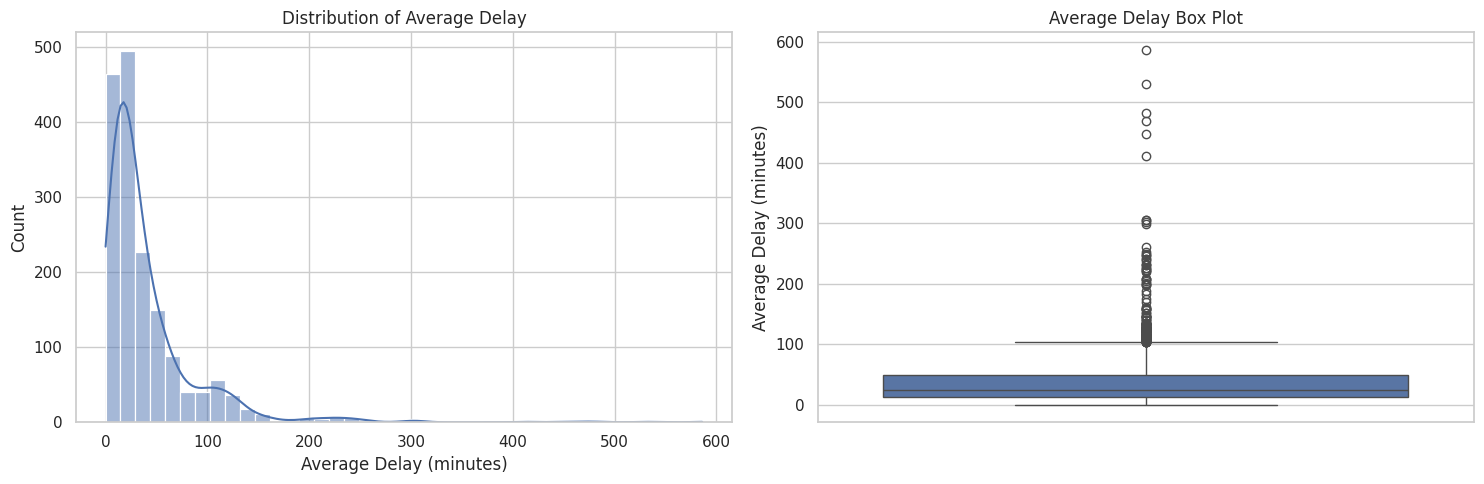

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(
    data=df,
    x="average_delay_minutes",
    bins=40,
    kde=True,
    ax=axes[0]
)
axes[0].set_title("Distribution of Average Delay")
axes[0].set_xlabel("Average Delay (minutes)")

sns.boxplot(
    data=df,
    y="average_delay_minutes",
    ax=axes[1]
)
axes[1].set_title("Average Delay Box Plot")
axes[1].set_ylabel("Average Delay (minutes)")

plt.tight_layout()
plt.show()


## 6. Delay Severity Distribution

This section shows how many train–station observations fall into each project-defined severity category.


,observations,percentage
delay_severity,,
On Time,18,1.081731
Minor,491,29.507212
Moderate,841,50.540865
Severe,314,18.870192


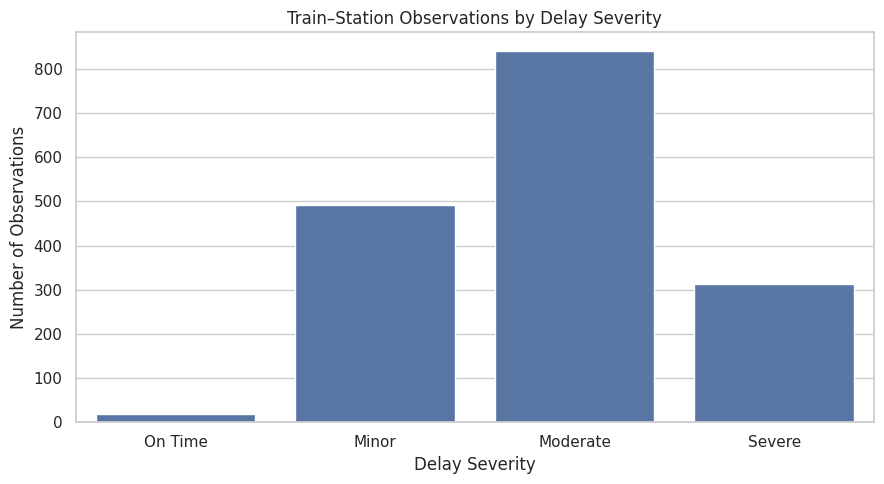

In [9]:
severity_order = ["On Time", "Minor", "Moderate", "Severe"]

severity_counts = (
    df["delay_severity"]
    .value_counts()
    .reindex(severity_order, fill_value=0)
)

display(
    severity_counts.to_frame("observations")
    .assign(percentage=lambda x: 100 * x["observations"] / x["observations"].sum())
)

plt.figure(figsize=(9, 5))
sns.barplot(
    x=severity_counts.index,
    y=severity_counts.values
)
plt.title("Train–Station Observations by Delay Severity")
plt.xlabel("Delay Severity")
plt.ylabel("Number of Observations")
plt.tight_layout()
plt.show()


## 7. Station-Level Analysis

We aggregate observations by station to identify locations with different historical punctuality profiles.

We require at least 3 observations per station for ranking so that a single observation does not dominate the analysis.


In [10]:
station_summary = (
    df.groupby(["station_code", "station_name"])
      .agg(
          observations=("train_number", "count"),
          avg_delay=("average_delay_minutes", "mean"),
          median_delay=("average_delay_minutes", "median"),
          avg_right_time=("pct_right_time", "mean"),
          avg_significant_delay=("pct_significant_delay", "mean")
      )
      .reset_index()
)

station_filtered = station_summary[station_summary["observations"] >= 3].copy()

print("Stations with at least 3 observations:", len(station_filtered))

top_delayed_stations = (
    station_filtered
    .sort_values("avg_delay", ascending=False)
    .head(15)
)

display(top_delayed_stations)


Stations with at least 3 observations: 193


,station_code,station_name,observations,avg_delay,median_delay,avg_right_time,avg_significant_delay
407,SLO,SAMALKOT JN,4,126.500000,126.5,8.220000,79.910000
309,NDD,NIDADAVOLU JN,4,124.000000,124.0,6.985000,70.870000
372,RJY,RAJAMUNDRY,6,122.166667,131.0,2.758333,75.606667
21,ANV,ANNAVARAM,4,119.000000,119.0,6.985000,70.185000
450,TUNI,TUNI,4,118.000000,118.0,8.790000,68.515000
15,AKP,ANAKAPALLE,4,117.000000,117.0,12.125000,68.080000
186,IPM,ICHCHPURAM,4,111.500000,111.5,15.615000,62.240000
91,CAP,CHATRAPUR,4,111.000000,111.0,1.235000,61.370000
434,TEL,TENALI JN,3,110.333333,127.0,10.593333,60.393333
66,BPP,BAPATLA,4,109.000000,109.0,9.040000,58.080000


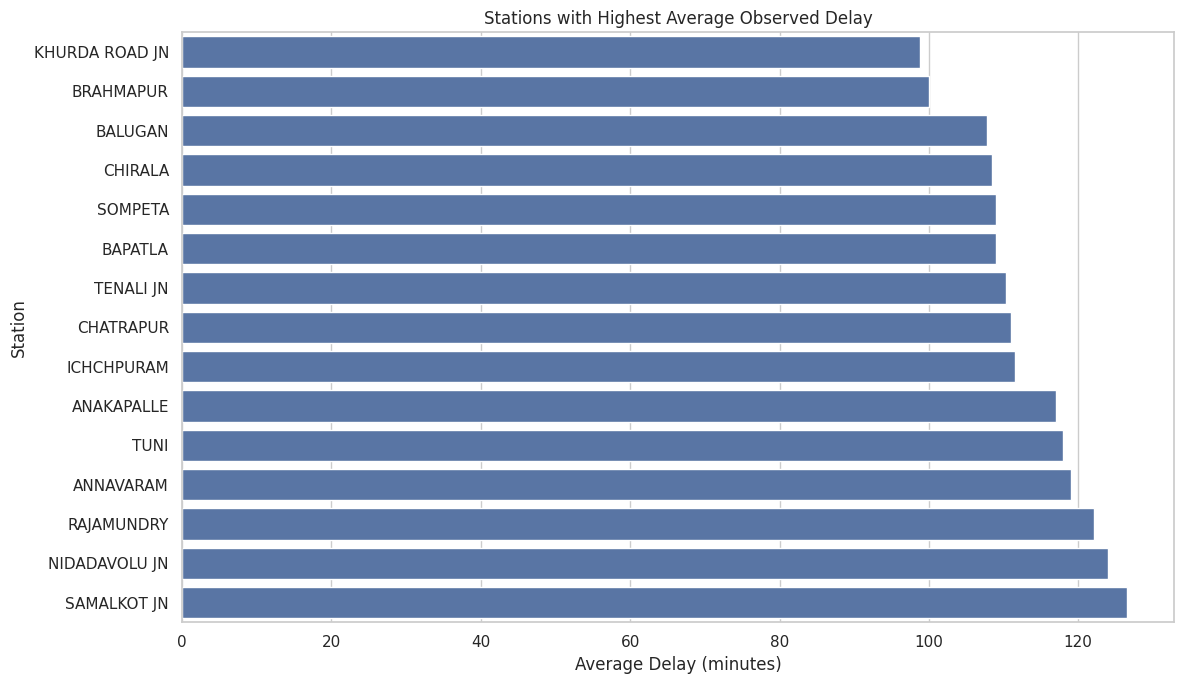

In [11]:
plt.figure(figsize=(12, 7))
plot_df = top_delayed_stations.sort_values("avg_delay")

sns.barplot(
    data=plot_df,
    x="avg_delay",
    y="station_name"
)
plt.title("Stations with Highest Average Observed Delay")
plt.xlabel("Average Delay (minutes)")
plt.ylabel("Station")
plt.tight_layout()
plt.show()


### Punctuality-focused station view

A station can have a high average delay but also a small number of observations. We therefore also inspect the proportion of right-time observations.


,station_code,station_name,observations,avg_delay,median_delay,avg_right_time,avg_significant_delay
286,MS,CHENNAI EGMORE,6,1.833333,1.5,98.535000,0.045000
268,MBM,MAMBALAM,3,5.333333,7.0,94.156667,0.640000
392,SDAH,SEALDAH,4,18.500000,9.5,91.980000,5.625000
302,NAD,NAGDA JN,5,13.200000,13.0,89.224000,4.638000
134,DNR,DANAPUR,3,6.666667,5.0,88.890000,4.446667
435,TEN,TIRUNELVELI JN,6,5.333333,2.5,88.751667,0.555000
277,MMCT,MUMBAI CENTRAL,8,7.500000,5.5,88.483750,2.272500
125,DHN,DHANBAD JN,7,10.142857,4.0,87.857143,2.884286
92,CBE,COIMBATORE JN,8,17.250000,2.0,86.318750,4.726250
423,ST,SURAT,10,13.700000,14.5,85.368000,4.042000


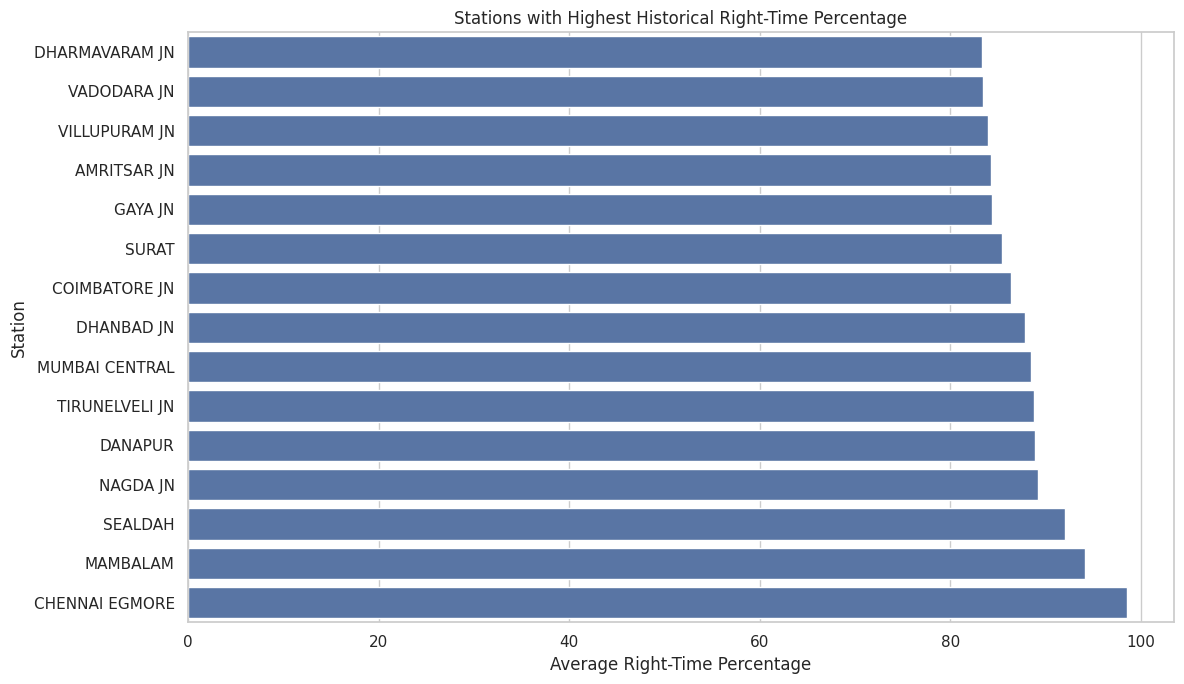

In [12]:
top_right_time = (
    station_filtered
    .sort_values("avg_right_time", ascending=False)
    .head(15)
)

display(top_right_time)

plt.figure(figsize=(12, 7))
plot_df = top_right_time.sort_values("avg_right_time")

sns.barplot(
    data=plot_df,
    x="avg_right_time",
    y="station_name"
)
plt.title("Stations with Highest Historical Right-Time Percentage")
plt.xlabel("Average Right-Time Percentage")
plt.ylabel("Station")
plt.tight_layout()
plt.show()


## 8. Train-Level Analysis

Now we examine which trains show different historical delay patterns.

The results should be interpreted as **historical observations in this dataset**, not as a universal ranking of Indian Railways trains.


In [13]:
train_summary = (
    df.groupby(["train_number", "train_name"])
      .agg(
          observations=("station_code", "count"),
          avg_delay=("average_delay_minutes", "mean"),
          median_delay=("average_delay_minutes", "median"),
          avg_right_time=("pct_right_time", "mean"),
          avg_significant_delay=("pct_significant_delay", "mean")
      )
      .reset_index()
)

train_filtered = train_summary[train_summary["observations"] >= 3].copy()

display(
    train_filtered
    .sort_values("avg_delay", ascending=False)
    .head(20)
)


,train_number,train_name,observations,avg_delay,median_delay,avg_right_time,avg_significant_delay
24,12261,Howrah Duronto,8,370.500000,305.0,18.660000,58.732500
25,12262,Howrah Duronto,6,316.833333,356.0,17.708333,69.791667
19,12236,Duronto Express,7,148.000000,152.0,35.714286,50.000000
40,12509,Guwahati Sbc Express,37,143.189189,197.0,14.639189,70.720811
56,12839,Howrah Mail,63,109.365079,106.0,7.143016,66.137778
45,12626,Kerala Express,39,101.051282,107.0,32.764359,29.764615
57,12840,Howrah Mail,70,100.814286,97.5,19.358000,47.976000
41,12510,Sbc Guwahati Express,38,87.973684,97.0,27.530000,49.393947
20,12245,Duronto Express,5,78.200000,93.0,31.818000,45.458000
59,12842,Coromandel Express,17,65.529412,63.0,20.195882,34.901765


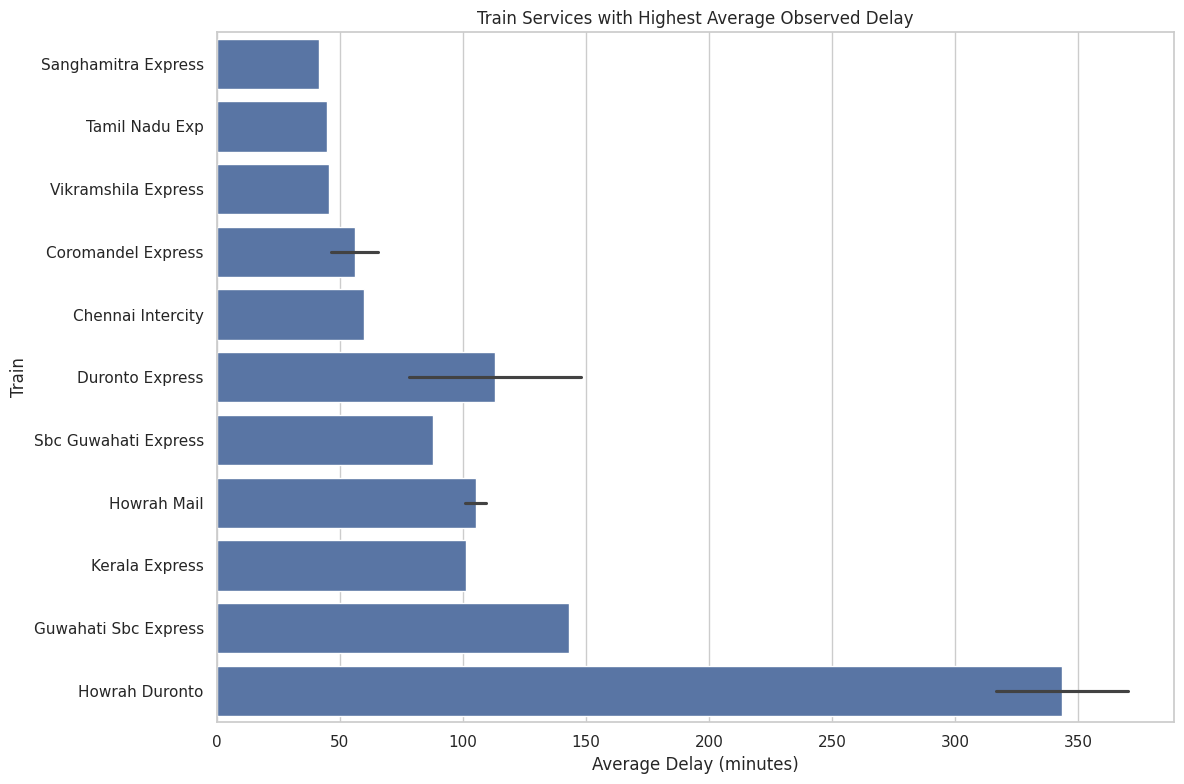

In [14]:
plt.figure(figsize=(12, 8))
plot_df = train_filtered.sort_values("avg_delay", ascending=False).head(15).sort_values("avg_delay")

sns.barplot(
    data=plot_df,
    x="avg_delay",
    y="train_name"
)
plt.title("Train Services with Highest Average Observed Delay")
plt.xlabel("Average Delay (minutes)")
plt.ylabel("Train")
plt.tight_layout()
plt.show()


## 9. Delay vs Punctuality Relationship

We examine whether the observed average delay is associated with the percentage of right-time observations and other delay components.

Correlation does not imply causation; these variables are different summaries of the same historical punctuality profile.


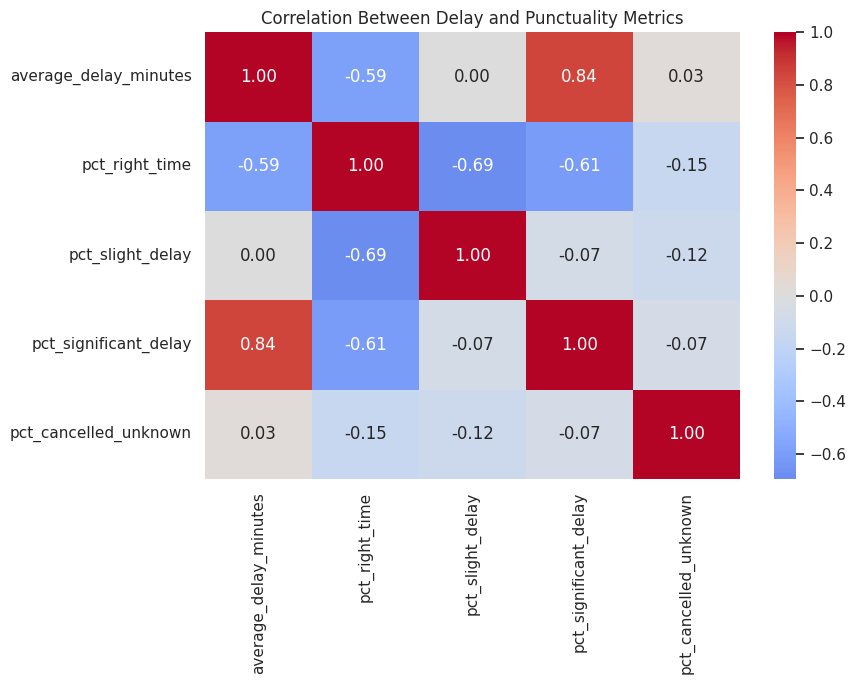

In [15]:
corr_cols = [
    "average_delay_minutes",
    "pct_right_time",
    "pct_slight_delay",
    "pct_significant_delay",
    "pct_cancelled_unknown"
]

corr = df[corr_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Between Delay and Punctuality Metrics")
plt.tight_layout()
plt.show()


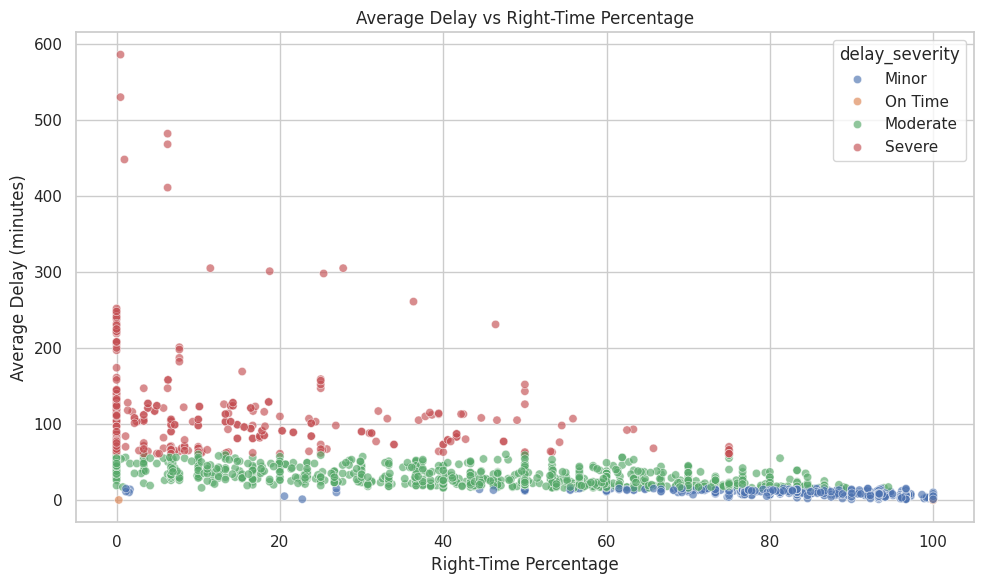

In [16]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="pct_right_time",
    y="average_delay_minutes",
    hue="delay_severity",
    alpha=0.65
)
plt.title("Average Delay vs Right-Time Percentage")
plt.xlabel("Right-Time Percentage")
plt.ylabel("Average Delay (minutes)")
plt.tight_layout()
plt.show()


## 10. AI Component — Delay Profile Clustering

### Why clustering?

The dataset does not contain a clean, real-world future-delay target. Instead of creating a misleading prediction model, we use **unsupervised learning** to discover naturally occurring delay profiles.

Each train–station observation is represented using historical punctuality characteristics:

- Average delay
- Right-time percentage
- Slight-delay percentage
- Significant-delay percentage
- Cancelled/unknown percentage

K-Means will group observations with similar delay behavior.

We will select the number of clusters using the **silhouette score**.


,k,silhouette_score
0,2,0.451210
1,3,0.492545
2,4,0.516364
3,5,0.437583
4,6,0.452481
5,7,0.449144
6,8,0.403684


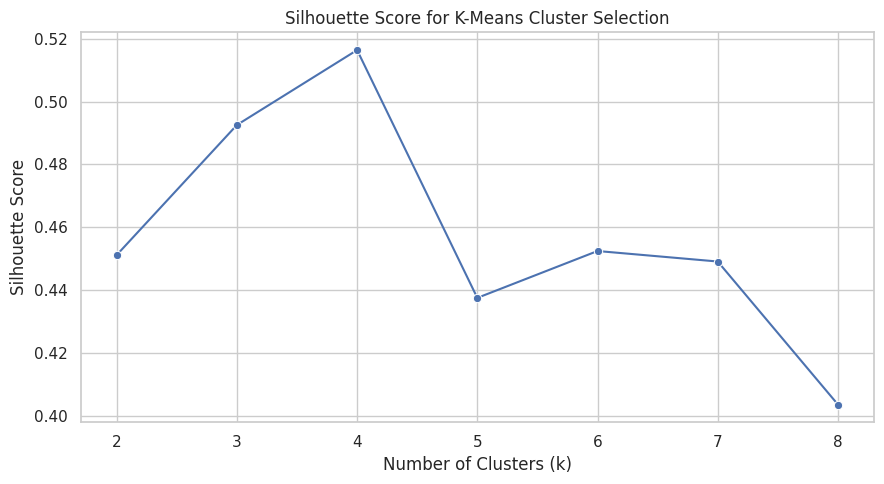

In [17]:
cluster_features = [
    "average_delay_minutes",
    "pct_right_time",
    "pct_slight_delay",
    "pct_significant_delay",
    "pct_cancelled_unknown"
]

X_cluster = df[cluster_features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

silhouette_results = []

for k in range(2, 9):
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_results.append((k, score))

silhouette_df = pd.DataFrame(
    silhouette_results,
    columns=["k", "silhouette_score"]
)

display(silhouette_df)

plt.figure(figsize=(9, 5))
sns.lineplot(
    data=silhouette_df,
    x="k",
    y="silhouette_score",
    marker="o"
)
plt.title("Silhouette Score for K-Means Cluster Selection")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(range(2, 9))
plt.tight_layout()
plt.show()


In [18]:
best_k = int(
    silhouette_df.loc[
        silhouette_df["silhouette_score"].idxmax(), "k"
    ]
)

print("Selected number of clusters:", best_k)

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=20
)

df["delay_cluster"] = kmeans.fit_predict(X_scaled)

cluster_profile = (
    df.groupby("delay_cluster")[cluster_features]
      .mean()
      .sort_values("average_delay_minutes")
)

display(cluster_profile)


Selected number of clusters: 4


,average_delay_minutes,pct_right_time,pct_slight_delay,pct_significant_delay,pct_cancelled_unknown
delay_cluster,,,,,
2,16.968930,77.277399,17.304948,5.270322,0.147929
0,44.568595,23.211008,61.174843,15.452182,0.162678
3,46.850000,7.508000,6.769000,1.933000,83.790000
1,147.511765,8.730059,19.217235,71.818235,0.234824


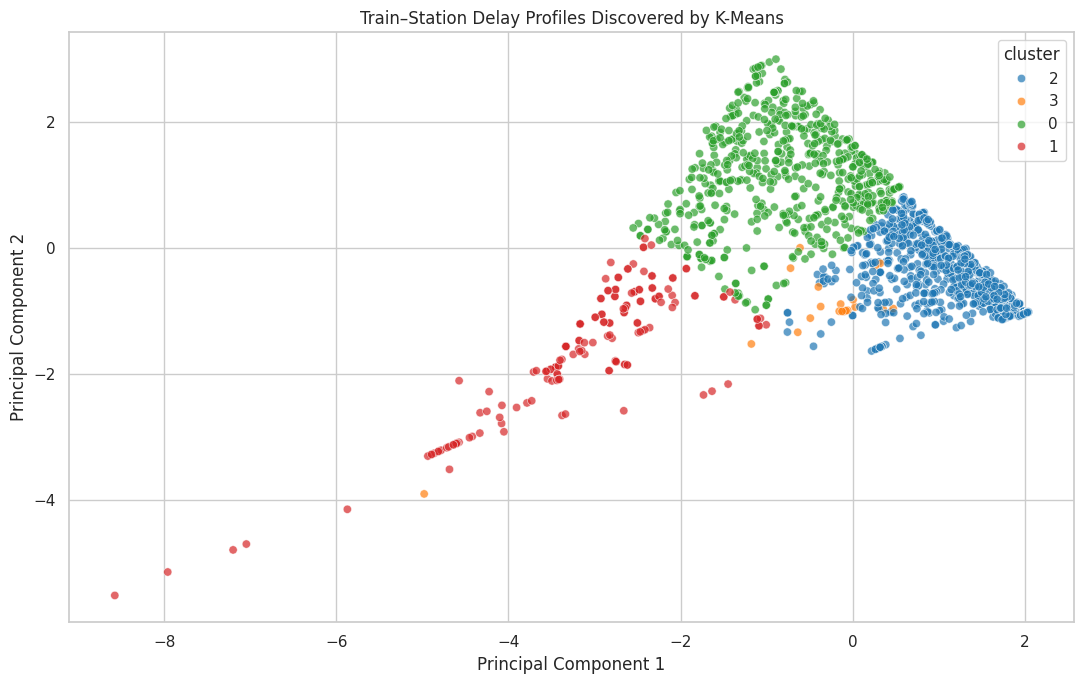

In [19]:
# PCA projection for 2D visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "cluster": df["delay_cluster"].astype(str).values
})

plt.figure(figsize=(11, 7))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="tab10",
    alpha=0.7
)
plt.title("Train–Station Delay Profiles Discovered by K-Means")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.tight_layout()
plt.show()


### Interpreting the clusters

The clusters should be described using their **average feature profiles**, rather than assigning arbitrary labels such as "good" or "bad" before inspecting the results.

For example, after seeing the cluster profile table, we may identify groups such as:

- high-punctuality / low-delay profile
- moderate-delay profile
- high-delay / low-punctuality profile

The actual interpretation must come from the computed results.


## 11. AI Component — Anomaly Detection

Some train–station observations may behave very differently from the majority.

We use **Isolation Forest** to identify unusual delay profiles.

This is an anomaly-detection task, not a claim that an observation represents an operational failure.


In [20]:
iso_features = [
    "average_delay_minutes",
    "pct_right_time",
    "pct_slight_delay",
    "pct_significant_delay",
    "pct_cancelled_unknown"
]

X_iso = df[iso_features].copy()
X_iso_scaled = StandardScaler().fit_transform(X_iso)

iso_model = IsolationForest(
    n_estimators=300,
    contamination="auto",
    random_state=42
)

df["anomaly_label"] = iso_model.fit_predict(X_iso_scaled)
df["anomaly_score"] = iso_model.decision_function(X_iso_scaled)

# -1 = anomaly, +1 = regular observation
anomalies = df[df["anomaly_label"] == -1].copy()

print("Total observations:", len(df))
print("Detected anomalies:", len(anomalies))

display(
    anomalies[
        [
            "train_number",
            "train_name",
            "station_code",
            "station_name",
            "average_delay_minutes",
            "pct_right_time",
            "pct_significant_delay",
            "anomaly_score"
        ]
    ]
    .sort_values("anomaly_score")
    .head(20)
)


Total observations: 1664
Detected anomalies: 239


,train_number,train_name,station_code,station_name,average_delay_minutes,pct_right_time,pct_significant_delay,anomaly_score
1379,12261,Howrah Duronto,AK,AKOLA JN,448.0,0.96,4.31,-0.272817
1388,12262,Howrah Duronto,AK,AKOLA JN,411.0,6.25,68.75,-0.242283
1383,12261,Howrah Duronto,HWH,HOWRAH JN,586.0,0.48,99.04,-0.227247
1382,12261,Howrah Duronto,TATA,TATANAGAR JN,530.0,0.48,99.04,-0.227083
1,12673,Cheran Express,AVD,AVADI,0.0,0.27,0.00,-0.219007
719,12163,Chennai Express,KOU,KODURU,45.0,0.00,0.00,-0.217949
329,12842,Coromandel Express,SHM,SHALIMAR,53.0,3.33,6.67,-0.217332
1712,12367,Vikramshila Express,PRYJ,PRAYAGRAJ JN,101.0,2.19,5.21,-0.217210
1825,15960,Kamrup Express,GOGH,GOSSAIGAON HAT,11.0,1.15,0.00,-0.209508
1764,15959,Kamrup Express,GOGH,GOSSAIGAON HAT,10.0,1.53,0.00,-0.208660


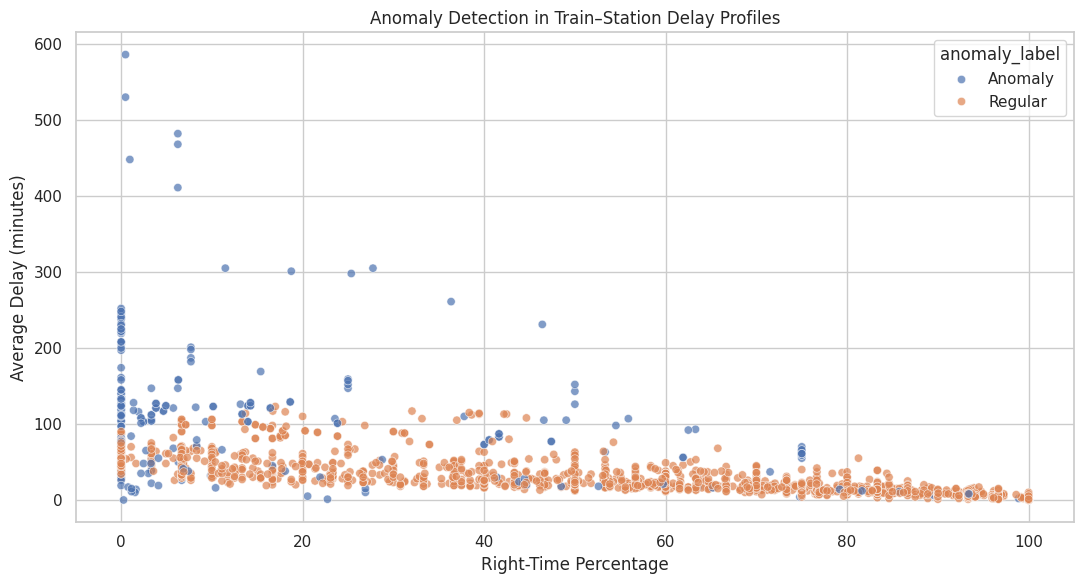

In [21]:
plt.figure(figsize=(11, 6))

sns.scatterplot(
    data=df,
    x="pct_right_time",
    y="average_delay_minutes",
    hue=df["anomaly_label"].map({1: "Regular", -1: "Anomaly"}),
    alpha=0.7
)

plt.title("Anomaly Detection in Train–Station Delay Profiles")
plt.xlabel("Right-Time Percentage")
plt.ylabel("Average Delay (minutes)")
plt.tight_layout()
plt.show()


## 12. Top Analytical Findings

The following cells generate data-backed tables that can be used when writing the final report.

**Do not manually invent findings.** Use the actual outputs from this notebook.


In [22]:
# Overall findings
print("=== OVERALL DATASET ===")
print(f"Train–station observations: {len(df):,}")
print(f"Unique trains: {df['train_number'].nunique():,}")
print(f"Unique stations: {df['station_code'].nunique():,}")
print(f"Mean average delay: {df['average_delay_minutes'].mean():.2f} minutes")
print(f"Median average delay: {df['average_delay_minutes'].median():.2f} minutes")
print(f"Mean right-time percentage: {df['pct_right_time'].mean():.2f}%")

print("\n=== HIGHEST-AVERAGE-DELAY STATIONS (min 3 observations) ===")
display(top_delayed_stations.head(10))

print("\n=== HIGHEST-AVERAGE-DELAY TRAINS (min 3 observations) ===")
display(
    train_filtered
    .sort_values("avg_delay", ascending=False)
    .head(10)
)

print("\n=== CLUSTER PROFILES ===")
display(cluster_profile)


=== OVERALL DATASET ===
Train–station observations: 1,664
Unique trains: 90
Unique stations: 476
Mean average delay: 40.70 minutes
Median average delay: 24.00 minutes
Mean right-time percentage: 49.78%

=== HIGHEST-AVERAGE-DELAY STATIONS (min 3 observations) ===


,station_code,station_name,observations,avg_delay,median_delay,avg_right_time,avg_significant_delay
407,SLO,SAMALKOT JN,4,126.500000,126.5,8.220000,79.910000
309,NDD,NIDADAVOLU JN,4,124.000000,124.0,6.985000,70.870000
372,RJY,RAJAMUNDRY,6,122.166667,131.0,2.758333,75.606667
21,ANV,ANNAVARAM,4,119.000000,119.0,6.985000,70.185000
450,TUNI,TUNI,4,118.000000,118.0,8.790000,68.515000
15,AKP,ANAKAPALLE,4,117.000000,117.0,12.125000,68.080000
186,IPM,ICHCHPURAM,4,111.500000,111.5,15.615000,62.240000
91,CAP,CHATRAPUR,4,111.000000,111.0,1.235000,61.370000
434,TEL,TENALI JN,3,110.333333,127.0,10.593333,60.393333
66,BPP,BAPATLA,4,109.000000,109.0,9.040000,58.080000



=== HIGHEST-AVERAGE-DELAY TRAINS (min 3 observations) ===


,train_number,train_name,observations,avg_delay,median_delay,avg_right_time,avg_significant_delay
24,12261,Howrah Duronto,8,370.500000,305.0,18.660000,58.732500
25,12262,Howrah Duronto,6,316.833333,356.0,17.708333,69.791667
19,12236,Duronto Express,7,148.000000,152.0,35.714286,50.000000
40,12509,Guwahati Sbc Express,37,143.189189,197.0,14.639189,70.720811
56,12839,Howrah Mail,63,109.365079,106.0,7.143016,66.137778
45,12626,Kerala Express,39,101.051282,107.0,32.764359,29.764615
57,12840,Howrah Mail,70,100.814286,97.5,19.358000,47.976000
41,12510,Sbc Guwahati Express,38,87.973684,97.0,27.530000,49.393947
20,12245,Duronto Express,5,78.200000,93.0,31.818000,45.458000
59,12842,Coromandel Express,17,65.529412,63.0,20.195882,34.901765



=== CLUSTER PROFILES ===


,average_delay_minutes,pct_right_time,pct_slight_delay,pct_significant_delay,pct_cancelled_unknown
delay_cluster,,,,,
2,16.968930,77.277399,17.304948,5.270322,0.147929
0,44.568595,23.211008,61.174843,15.452182,0.162678
3,46.850000,7.508000,6.769000,1.933000,83.790000
1,147.511765,8.730059,19.217235,71.818235,0.234824


## 13. Conclusions

Use the actual outputs above to write 4–8 evidence-based conclusions.

A strong conclusion should contain:

1. What was observed?
2. What evidence supports it?
3. What does it mean for railway punctuality analytics?
4. What limitation should be considered?

### Example structure

> The analysis identified distinct train–station punctuality profiles. The clustering analysis grouped observations according to their historical delay characteristics, while Isolation Forest highlighted observations with unusual combinations of delay and punctuality metrics. These results demonstrate how unsupervised machine learning can support exploratory railway performance analysis.

**Replace generic wording with your actual numerical findings after running the notebook.**


## 14. Limitations

This project has several important limitations:

- The dataset contains aggregated historical train–station delay statistics.
- It does not provide every individual journey's actual and scheduled arrival time.
- It does not contain complete weather, track, congestion, signaling, maintenance, crew, or operational data.
- Historical association should not be interpreted as causal evidence.
- The clustering and anomaly-detection results depend on the selected features and preprocessing choices.
- The project-defined delay severity thresholds are analytical categories and are not official Indian Railways classifications.
- Results describe the provided dataset and collection period; they should not be generalized to all Indian railway operations without additional representative data.


## 15. Future Scope

A more advanced version of RailSense could integrate:

- Official Indian Railways timetable data
- Weather data
- Train route and distance information
- Historical train-level punctuality
- Station congestion indicators
- Holiday/festival calendars
- Weather disruptions such as heavy rain or fog
- Real-time train running information

With genuine journey-level data, a future model could predict:

**Expected delay in minutes** or **probability of arriving more than 15 minutes late** before or during a journey.


## 16. Dataset & Source

**Dataset file:** `etrain_delays.csv`

The dataset includes a `source_url` column containing the original source associated with each observation.

Before final submission, verify the dataset's source/license information and add the exact source URL to the project `README.md`.

